<a href="https://colab.research.google.com/github/Priyanshu5266/bpta/blob/main/Priyanshu_bpta_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random

In [ ]:
import networkx as nx

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pickle
import time

In [ ]:
n=10

In [ ]:
m_value =[10,15,20,25,30,35,40,45]

In [ ]:
all_edges =[]

for i in range (n):
  for j in range (i+1,n):
    all_edges.append((i,j))

In [ ]:
random.seed(3)
datasets = {}
for m in m_value:
  edges= random.sample(all_edges,m)
  datasets[m] = edges

In [ ]:
with open ("vertex_dataset.pkl","wb") as file:
  pickle.dump(datasets,file)

print ("save")

save


In [ ]:
def is_vertex_cover(cover, edges):
  for edge in edges:
    u = edge[0]
    v = edge[1]
    if u not in cover and v not in cover:
        return False
  return True

In [ ]:
def brute_force_vertex_cover(n, edges):
    best_cover = None
    for mask in range(2 ** n):
        cover = []
        for i in range(n):
            if mask & (1 << i):
                cover.append(i)
        if is_vertex_cover(cover, edges):
            if best_cover is None or len(cover) < len(best_cover):
                best_cover = cover
    return best_cover

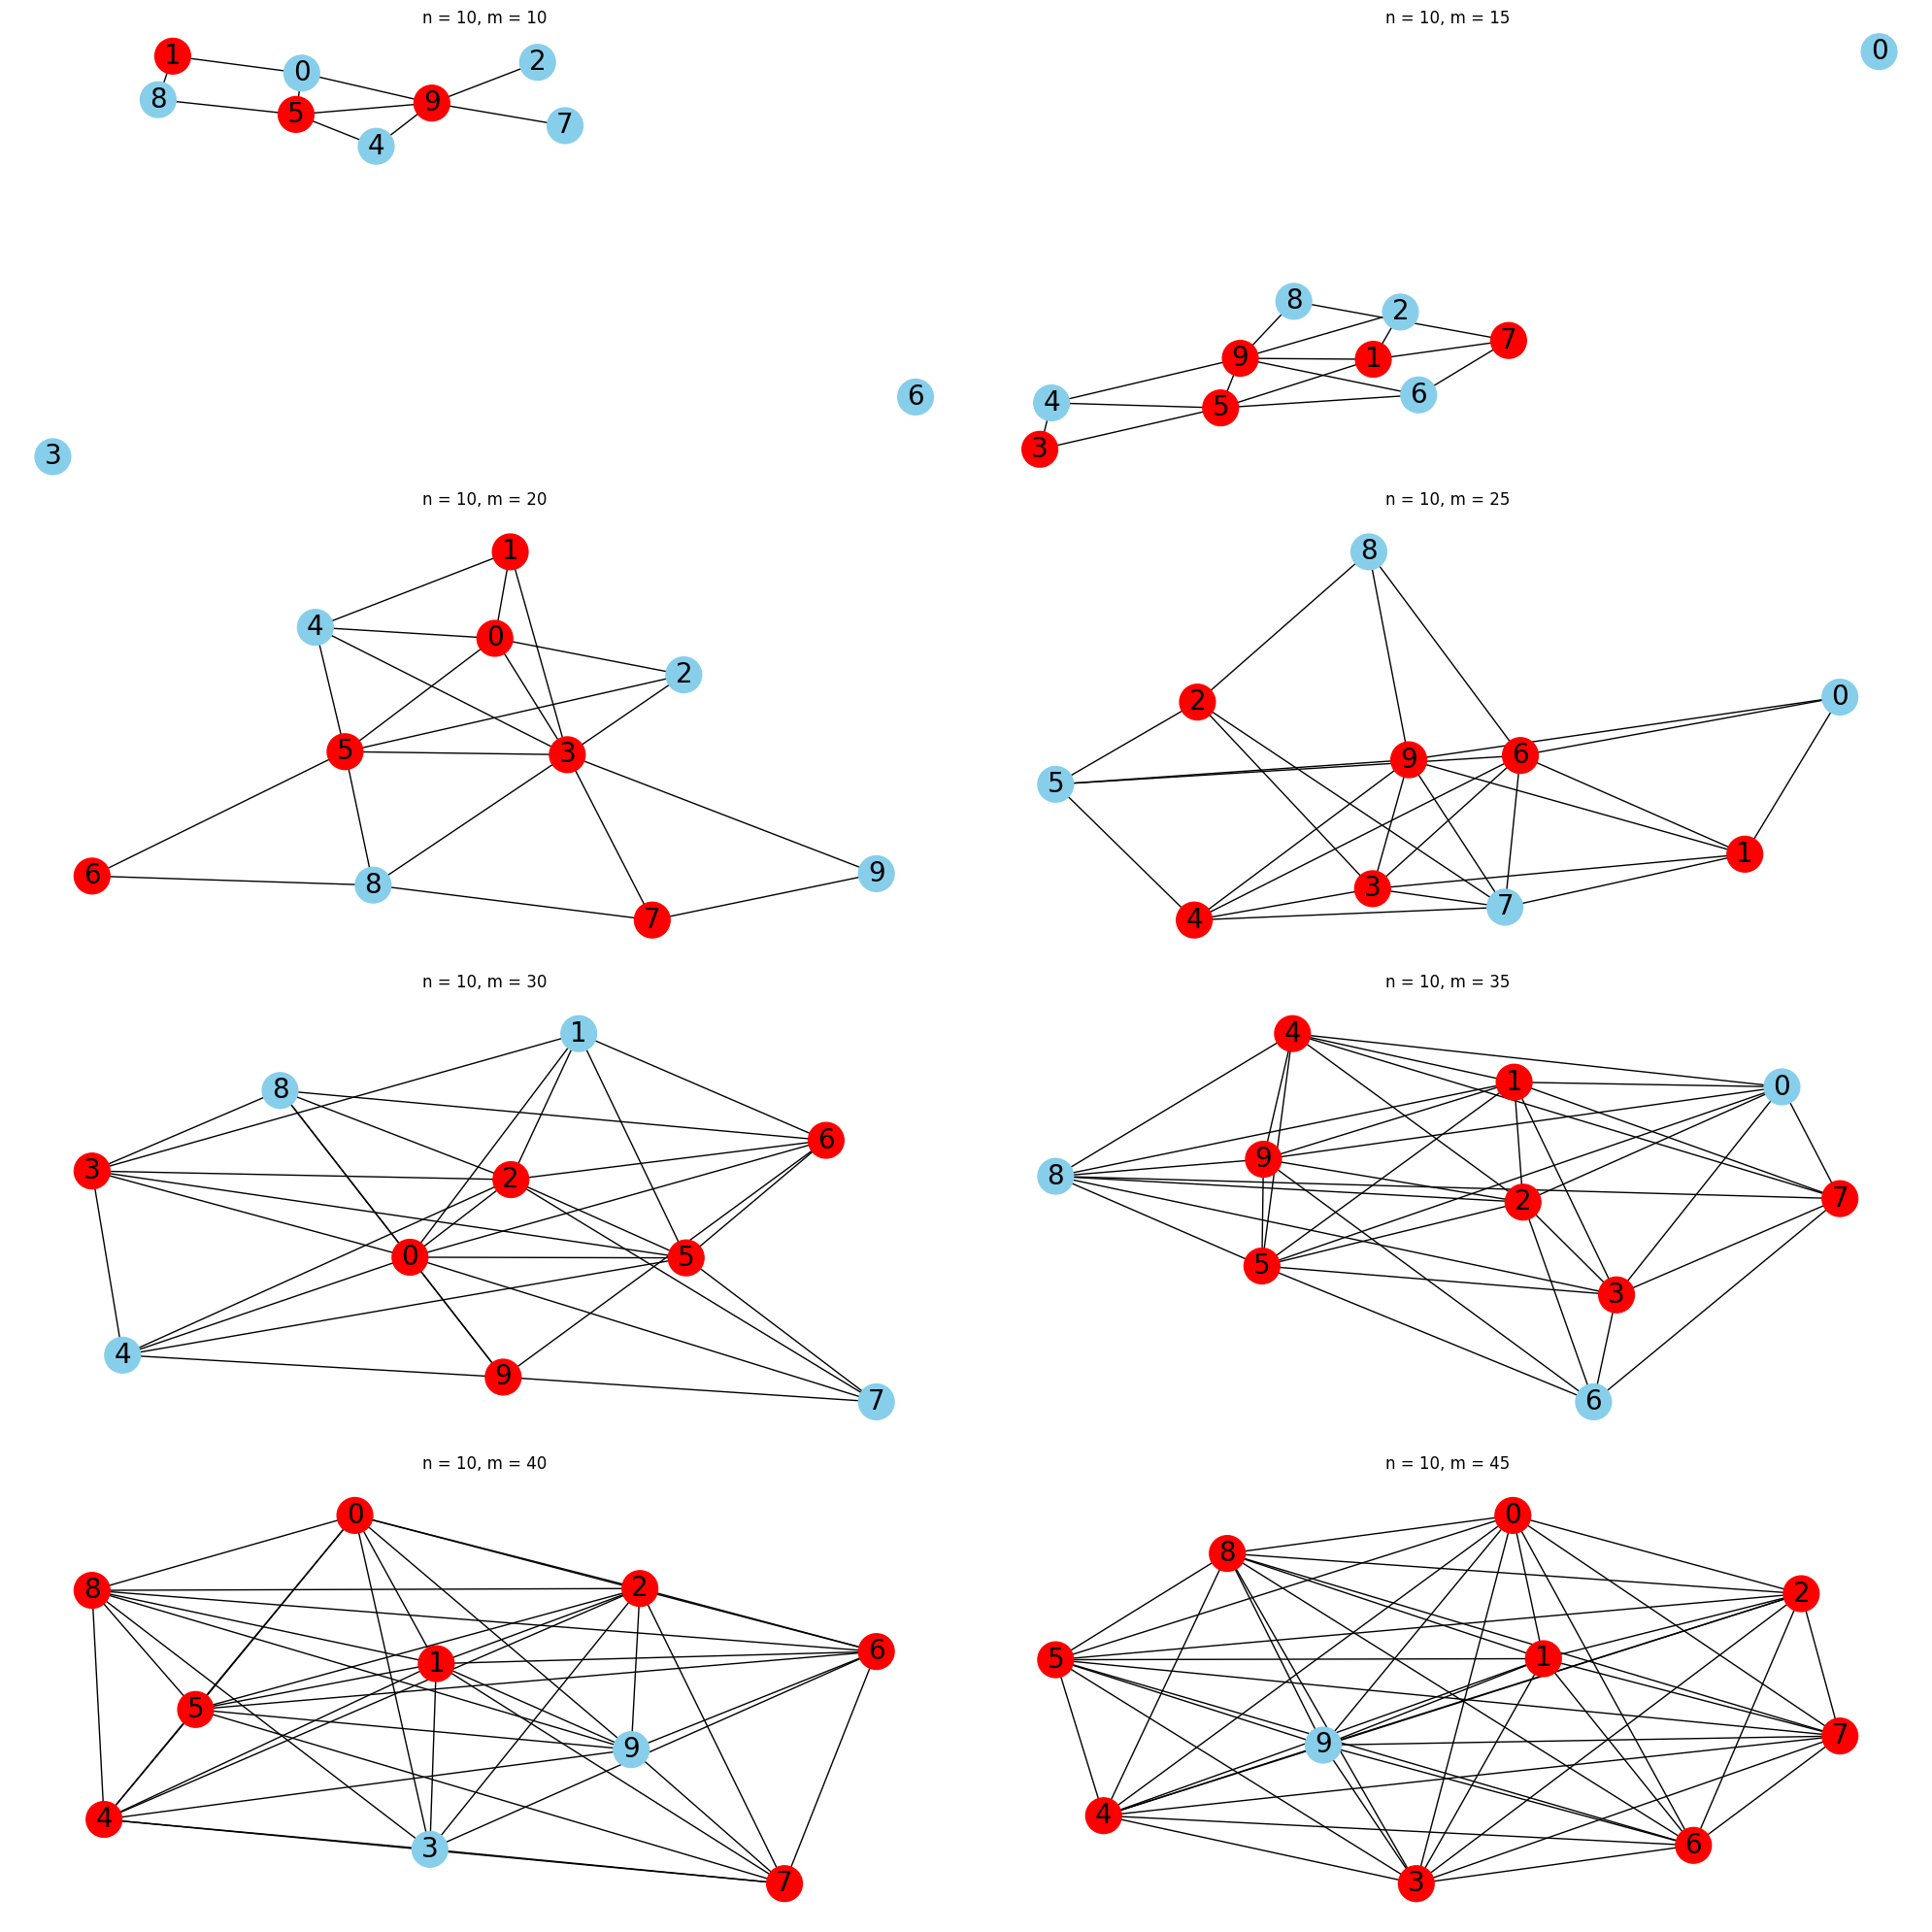

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))

for ax, m in zip(axes.flat, m_value):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    G.add_edges_from(datasets[m])
    cover = brute_force_vertex_cover(n, datasets[m])

    node_colors = []

    for node in G.nodes():
        if node in cover:
            node_colors.append("red")
        else:
            node_colors.append("skyblue")
    pos = nx.spring_layout(G, seed=3)
    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=700,
        font_size=20,
        width=1,
        node_color=node_colors
    )

    ax.set_title("n = 10, m = " + str(m))


plt.tight_layout()
plt.savefig(
    "vertex_cover_colored_graphs.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [ ]:
results = []
for m in m_value:
  edges = datasets[m]
  start_time = time.perf_counter()
  cover = brute_force_vertex_cover(n, edges)
  end_time = time.perf_counter()
  running_time = end_time - start_time
  cover_size = len(cover)
  results.append((n, m, cover_size, running_time))

In [ ]:
print()
print("=" * 60)
print("n,m\t |Vertex Cover Size|\t|Running Time (seconds)|")
print("=" * 60)
for result in results:
  n_value = result[0]
  m_value = result[1]
  cover_size = result[2]
  running_time = result[3]
  print(n_value,m_value,"\t\t",cover_size, "\t\t",running_time )




n,m	 |Vertex Cover Size|	|Running Time (seconds)|
10 10 		 3 		 0.0031115369999952236
10 15 		 5 		 0.0036082539999711116
10 20 		 6 		 0.0022130859999833774
10 25 		 6 		 0.001762637000013001
10 30 		 6 		 0.00187906900004009
10 35 		 7 		 0.0022076039999774366
10 40 		 8 		 0.0016881820000094194
10 45 		 9 		 0.0017622380000261728


In [ ]:
with open("vertex_cover_results.pkl", "wb") as file:
  pickle.dump(results, file)
  print()
  print("Results saved successfully.")



Results saved successfully.
